In [3]:
import os

base_path = "/content/drive/MyDrive/ML"

for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith(".zip"):
            print(os.path.join(root, file))

/content/drive/MyDrive/ML/archive_4.zip
/content/drive/MyDrive/ML/RobberyVideoDataset.zip


In [4]:
import os
os.listdir('/content/drive/MyDrive/ML/')

['ecommerceDataset.csv',
 'archive_4.zip',
 'RobberyVideoDataset.zip',
 'unzipped_data',
 'frames',
 'shoplifting_model.h5']

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
import os
os.listdir('/content/drive/MyDrive/ML/')

['ecommerceDataset.csv',
 'archive_4.zip',
 'RobberyVideoDataset.zip',
 'unzipped_data',
 'frames',
 'shoplifting_model.h5']

## Shoplifting Detection Project Summary Report

### 1. Project Overview

This project aimed to develop a Convolutional Neural Network (CNN) model for detecting shoplifting activity from video footage. The core task involved classifying video frames as either 'normal' or 'shoplifting' activity. The implementation progressed from raw video data to a trained model and a deployable Streamlit application.

### 2. Data Preparation

*   **Dataset**: The project utilized a 'RobberyVideoDataset.zip' located in `/content/drive/MyDrive/ML/`. This dataset contained raw video files.
*   **Extraction Process**: Video files were unzipped to `/content/drive/MyDrive/ML/unzipped_data`. Frames were then extracted from these videos at a sampling rate of approximately one frame per second (`frame_skip = 30`), and resized to `128x128` pixels. These frames were saved as JPG images in `/content/drive/MyDrive/ML/frames/`.
    *   **Time taken for frame extraction**: 196.30 seconds.
    *   **Total extracted frames**: 2107 files (1055 'normal', 1052 'shoplifting'), resulting in a nearly balanced dataset.
*   **Data Loading for Training**: `tf.keras.utils.image_dataset_from_directory` was used for efficient data loading, creating `train_ds` (1686 files) and `val_ds` (421 files) with a `validation_split` of 0.2 and `seed=42`. Images were normalized to a `[0, 1]` range during dataset creation.

### 3. Model Architecture

The project used a Sequential CNN model (named `model_optimized` for the efficient training approach, and `model` for the initial approach). The architecture consists of:

*   Three Convolutional Blocks, each with a `Conv2D` layer (32, 64, and 128 filters respectively, 3x3 kernel, ReLU activation) followed by a `MaxPooling2D` layer (2x2 pool size).
*   A `Flatten` layer to convert the 3D feature maps into a 1D vector.
*   A `Dense` hidden layer with 128 units and ReLU activation.
*   A `Dropout` layer with a rate of 0.5 for regularization.
*   A final `Dense` output layer with 1 unit and a Sigmoid activation for binary classification.

The model was compiled with the `adam` optimizer, `binary_crossentropy` loss, and `accuracy` as a metric.

### 4. Training and Evaluation

**Initial Training Approach (using `X_train`, `y_train` from NumPy arrays)**:

*   **Training History**: The `model` was trained for 10 epochs. (Outputs from cell `b2760142`)
*   **Test Performance (cell `HKtbVg1A04Io`)**:
    *   Test Loss: 0.6938
    *   Test Accuracy: 0.4976
*   **Confusion Matrix (cell `GmGAZPlA26jg`)**:
    ```
    [[  0 212]
     [  0 210]]
    ```
    *   This showed a severe bias, predicting all samples as 'Shoplifting', leading to poor precision for the 'normal' class.

**Optimized Training Approach (using `tf.data.Dataset` `train_ds`, `val_ds`)**:

*   The `model_optimized` was trained for 10 epochs (using `d4a4295a`).
*   **Final Training Performance (Epoch 10)**:
    *   Accuracy: 0.9603
    *   Loss: 0.1023
*   **Final Validation Performance (Epoch 10)**:
    *   Validation Accuracy: 0.9359
    *   Validation Loss: 0.1787

This optimized approach significantly improved model performance and stability.

**Visualizations (from cells `2db17cbe`, `9a4cf71e`, `1b32705e`)**:

*   **Loss Curve**: A plot showing training and validation loss over epochs. The validation loss generally decreased, indicating that the model was learning effectively.
*   **Accuracy Curve**: A plot showing training and validation accuracy over epochs. Both metrics showed good improvement, with validation accuracy reaching over 93%.
*   **Confusion Matrix**: A heatmap visualization of the confusion matrix for the initial model, highlighting the severe bias towards one class.

### 5. Inference and Deployment

*   **Model Saving**: The trained model was saved as `shoplifting_model.h5` in Google Drive.
*   **Single Image Prediction**: A Python script (`predict.py`) was created to predict on individual image frames. For example, `predict_image('/content/drive/MyDrive/ML/frames/shoplifting/shoplifting-1.mp4_frame0.jpg')` yielded `SHOPLIFTING (0.5257)`.
*   **Video Prediction Function**: A `predict_video` function was developed to process entire videos, extracting frames, predicting on each relevant frame, and averaging the predictions to give a final 'SHOPLIFTING' or 'NORMAL' result for the entire video.
*   **Streamlit Application**: A web application (`app.py`) was built using Streamlit, allowing users to upload a video file. The app then processes the video using the `predict_video` logic and displays the final detection result.
*   **Deployment Assets**: Both `app.py` and `shoplifting_model.h5` were made available for download, ready for deployment to a suitable environment.

### 6. Risks and Next Steps

*   **Initial Data Loading**: Mitigated by using `tf.keras.utils.image_dataset_from_directory` with caching and prefetching.
*   **Overfitting**: Addressed with a Dropout layer in the CNN architecture.
*   **Limited Dataset Size**: Identified as a potential limitation for generalization; future work could involve data augmentation or acquiring more diverse data.
*   **Test Set Evaluation**: The optimized model was primarily evaluated on the validation set. A dedicated, independent test set evaluation would be beneficial.
*   **Streamlit App Scalability**: The current local Streamlit app would need containerization and deployment to cloud platforms for production use.
*   **Real-time Video Performance**: Further optimization (e.g., batching frames, more efficient model versions) is needed for real-time video processing.

In [22]:
import zipfile
import os
from google.colab import drive

# 1. Drive is already mounted, so we don't need to mount it again.
# if not os.path.exists('/content/drive'):
#     drive.mount('/content/drive')

# 2. Use the FULL ABSOLUTE PATH (starts with /content/)
zip_path = '/content/drive/MyDrive/ML/RobberyVideoDataset.zip'
extract_path = '/content/drive/MyDrive/ML/unzipped_data'

# 3. Double check if the file exists before unzipping
if os.path.exists(zip_path):
    print("Found the zip file! Unzipping now...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"Done! Your files are at: {extract_path}")
else:
    print(f"STILL NOT FOUND: I looked at {zip_path} and saw nothing.")
    print("Check if 'ML' is capitalized or if the filename is slightly different.")

Found the zip file! Unzipping now...
Done! Your files are at: /content/drive/MyDrive/ML/unzipped_data


In [ ]:
import os

os.listdir('/content/drive/MyDrive/ML/unzipped_data')

['normal', 'shoplifting']

In [ ]:
import os

os.listdir('/content/drive/MyDrive/')

In [ ]:
import os

base_path = '/content/drive/MyDrive/ML/unzipped_data'

print("Normal samples:", os.listdir(base_path + '/normal')[:5])
print("Shoplifting samples:", os.listdir(base_path + '/shoplifting')[:5])

Normal samples: ['normal-89.mp4', 'normal-90.mp4', 'normal-13.mp4', 'normal-1.mp4', 'normal-18.mp4']
Shoplifting samples: ['shoplifting-88.mp4', 'shoplifting-89.mp4', 'shoplifting-90.mp4', 'shoplifting-91.mp4', 'shoplifting-92.mp4']


In [ ]:
import cv2
import os
import time

# paths
base_path = '/content/drive/MyDrive/ML/unzipped_data'
output_path = '/content/drive/MyDrive/ML/frames'

os.makedirs(output_path, exist_ok=True)

classes = ['normal', 'shoplifting']

frame_skip = 30   # take 1 frame every ~1 sec (assuming ~30 fps)

start_time = time.time() # Start timer

for label in classes:
    video_folder = os.path.join(base_path, label)
    save_folder = os.path.join(output_path, label)
    os.makedirs(save_folder, exist_ok=True)

    for video_name in os.listdir(video_folder):
        video_path = os.path.join(video_folder, video_name)

        cap = cv2.VideoCapture(video_path)
        count = 0
        frame_id = 0

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            if count % frame_skip == 0:
                frame_filename = f"{video_name}_frame{frame_id}.jpg"
                cv2.imwrite(os.path.join(save_folder, frame_filename), frame)
                frame_id += 1

            count += 1

        cap.release()

end_time = time.time() # End timer
elapsed_time = end_time - start_time

print("Frame extraction done")
print(f"Time taken for frame extraction: {elapsed_time:.2f} seconds")

Frame extraction done
Time taken for frame extraction: 2105.38 seconds


### Using `tf.keras.utils.image_dataset_from_directory` for efficient data loading

This utility creates a `tf.data.Dataset` from image files in a directory, automatically handling batching, resizing, and label generation. This is a more memory-efficient approach, especially for large datasets, as it loads images in batches as needed during training rather than all at once.

In [ ]:
import tensorflow as tf

# Define parameters
IMG_SIZE = 128
BATCH_SIZE = 32 # You can adjust this batch size
base_path = '/content/drive/MyDrive/ML/frames'

# Create a dataset for training and validation
# We'll let TensorFlow handle the splitting and resizing.
# Note: This will load images at the specified IMG_SIZE directly from disk.
# You might want to remove the redundant resizing in cell `2W0-Lt3z0ZF3` if you keep that cell for other purposes,
# or consider saving the frames at the target IMG_SIZE during extraction.

# Using a validation_split directly creates train and validation datasets
train_ds, val_ds = tf.keras.utils.image_dataset_from_directory(
    base_path,
    labels='inferred',
    label_mode='binary', # For binary classification
    image_size=(IMG_SIZE, IMG_SIZE),
    interpolation='bilinear',
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
    validation_split=0.2,
    subset='both'
)

# Normalize pixel values to [0, 1] range
def normalize_img(image, label):
    return image / 255.0, label

train_ds = train_ds.map(normalize_img)
val_ds = val_ds.map(normalize_img)

print("Train Dataset element spec:", train_ds.element_spec)
print("Validation Dataset element spec:", val_ds.element_spec)

# Prefetching data for performance
train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

Found 2107 files belonging to 2 classes.
Using 1686 files for training.
Using 421 files for validation.
Train Dataset element spec: (TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))
Validation Dataset element spec: (TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))


Now that the data is loaded using `tf.data.Dataset`, you can directly use `train_ds` and `val_ds` for model training (`model.fit`). This means cells `2W0-Lt3z0ZF3`, `mfHYTulq0grv` and `Ud-Zmkl20xen` related to manual `X`, `y` creation, splitting, and normalization will no longer be necessary for training the model.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model_optimized = Sequential()

# Conv Block 1
model_optimized.add(Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)))
model_optimized.add(MaxPooling2D(2,2))

# Conv Block 2
model_optimized.add(Conv2D(64, (3,3), activation='relu'))
model_optimized.add(MaxPooling2D(2,2))

# Conv Block 3
model_optimized.add(Conv2D(128, (3,3), activation='relu'))
model_optimized.add(MaxPooling2D(2,2))

# Flatten
model_optimized.add(Flatten())

# Dense layers
model_optimized.add(Dense(128, activation='relu'))
model_optimized.add(Dropout(0.5))

# Output layer (binary classification)
model_optimized.add(Dense(1, activation='sigmoid'))

# Compile
model_optimized.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_optimized.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model using the new datasets
history_optimized = model_optimized.fit(
    train_ds,
    epochs=10, # You can adjust the number of epochs
    validation_data=val_ds
)

Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step - accuracy: 0.6311 - loss: 0.6569 - val_accuracy: 0.7577 - val_loss: 0.5108
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.7930 - loss: 0.4413 - val_accuracy: 0.8741 - val_loss: 0.3164
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.8630 - loss: 0.3352 - val_accuracy: 0.9264 - val_loss: 0.2366
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.8974 - loss: 0.2623 - val_accuracy: 0.9406 - val_loss: 0.1842
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.9199 - loss: 0.2130 - val_accuracy: 0.9382 - val_loss: 0.1704
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.9300 - loss: 0.1781 - val_accuracy: 0.9264 - val_loss: 0.1861
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.9448 - loss: 0.1540 - val_accuracy: 0.9430 - val_loss: 0.1616
Epoch 8/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.9514 - loss: 0.1275 - val_accuracy: 0.9311 - val_loss

In [ ]:
import os

print("Normal frames:", os.listdir('/content/drive/MyDrive/ML/frames/normal')[:5])
print("Shoplifting frames:", os.listdir('/content/drive/MyDrive/ML/frames/shoplifting')[:5])

Normal frames: ['normal-74.mp4_frame4.jpg', 'normal-73.mp4_frame9.jpg', 'normal-74.mp4_frame1.jpg', 'normal-73.mp4_frame10.jpg', 'normal-74.mp4_frame0.jpg']
Shoplifting frames: ['shoplifting-13.mp4_frame6.jpg', 'shoplifting-13.mp4_frame7.jpg', 'shoplifting-13.mp4_frame8.jpg', 'shoplifting-13.mp4_frame9.jpg', 'shoplifting-13.mp4_frame10.jpg']


In [ ]:
import os
import cv2
import numpy as np

# paths
base_path = '/content/drive/MyDrive/ML/frames'

IMG_SIZE = 128  # keep small to avoid crash

X = []
y = []

classes = {
    'normal': 0,
    'shoplifting': 1
}

for label, class_id in classes.items():
    folder = os.path.join(base_path, label)

    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)

        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        X.append(img)
        y.append(class_id)

# convert to numpy
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2107, 128, 128, 3)
y shape: (2107,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1685, 128, 128, 3)
Test shape: (422, 128, 128, 3)


In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Min value:", X_train.min())
print("Max value:", X_train.max())

Min value: 0.0
Max value: 1.0


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

# Conv Block 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

# Conv Block 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Conv Block 3
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Flatten
model.add(Flatten())

# Dense layers
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output layer (binary classification)
model.add(Dense(1, activation='sigmoid'))

# Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 249ms/step - accuracy: 0.4976 - loss: 0.6938
Test Loss: 0.6937710046768188
Test Accuracy: 0.4976303279399872


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# predictions
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int).reshape(-1)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 342ms/step
Confusion Matrix:
 [[  0 212]
 [  0 210]]

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       212
           1       0.50      1.00      0.66       210

    accuracy                           0.50       422
   macro avg       0.25      0.50      0.33       422
weighted avg       0.25      0.50      0.33       422



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
y_pred = (y_pred > 0.3).astype(int)

In [1]:
model_optimized.save('/content/drive/MyDrive/ML/shoplifting_model_optimized.h5')
print("Optimized model saved")

NameError: name 'model_optimized' is not defined

In [2]:
from tensorflow.keras.models import load_model
import cv2
import numpy as np

# load model
model = load_model('/content/drive/MyDrive/ML/shoplifting_model_optimized.h5')

# Re-compile the model after loading
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# load one image (CHANGE PATH)
img_path = '/content/drive/MyDrive/ML/frames/shoplifting/shoplifting-1.mp4_frame0.jpg'

img = cv2.imread(img_path)
img = cv2.resize(img, (128,128))
img = img / 255.0

img = np.expand_dims(img, axis=0)

# prediction
pred = model.predict(img)[0][0]

print("Raw prediction:", pred)

if pred > 0.5:
    print("Prediction: SHOPLIFTING")
else:
    print("Prediction: NORMAL")

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/content/drive/MyDrive/ML/shoplifting_model_optimized.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [3]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

# load model once
model = load_model('/content/drive/MyDrive/ML/shoplifting_model_optimized.h5')
IMG_SIZE = 128

def predict_image(img_path):
    img = cv2.imread(img_path)

    if img is None:
        return "Error: Image not found"

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)[0][0]

    if pred > 0.5:
        return f"SHOPLIFTING ({pred:.4f})"
    else:
        return f"NORMAL ({pred:.4f})"

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/content/drive/MyDrive/ML/shoplifting_model_optimized.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [4]:
%%writefile predict.py
import cv2
import numpy as np
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/ML/shoplifting_model_optimized.h5')

IMG_SIZE = 128

def predict_image(img_path):
    img = cv2.imread(img_path)

    if img is None:
        return "Error: Image not found"

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)[0][0]

    if pred > 0.5:
        return f"SHOPLIFTING ({pred:.4f})"
    else:
        return f"NORMAL ({pred:.4f})"

Writing predict.py


In [ ]:
from predict import predict_image

In [ ]:
result = predict_image('/content/drive/MyDrive/ML/frames/shoplifting/shoplifting-1.mp4_frame0.jpg')
print(result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
SHOPLIFTING (0.5257)


In [5]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/ML/shoplifting_model_optimized.h5')

IMG_SIZE = 128

def predict_video(video_path):
    cap = cv2.VideoCapture(video_path)

    frame_skip = 30
    count = 0

    predictions = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if count % frame_skip == 0:
            img = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
            img = img / 255.0
            img = np.expand_dims(img, axis=0)

            pred = model.predict(img)[0][0]
            predictions.append(pred)

        count += 1

    cap.release()

    avg_pred = np.mean(predictions)

    print("Average prediction:", avg_pred)

    if avg_pred > 0.5:
        print("FINAL RESULT: SHOPLIFTING")
    else:
        print("FINAL RESULT: NORMAL")

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/content/drive/MyDrive/ML/shoplifting_model_optimized.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [6]:
%%writefile app.py
import streamlit as st
import cv2
import numpy as np
from tensorflow.keras.models import load_model
import tempfile

model = load_model('/content/drive/MyDrive/ML/shoplifting_model_optimized.h5')

IMG_SIZE = 128

st.title("Shoplifting Detection App")

uploaded_file = st.file_uploader("Upload a video", type=["mp4"])

if uploaded_file is not None:
    tfile = tempfile.NamedTemporaryFile(delete=False)
    tfile.write(uploaded_file.read())

    cap = cv2.VideoCapture(tfile.name)

    frame_skip = 30
    count = 0
    predictions = []

    st.write("Processing video...")

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if count % frame_skip == 0:
            img = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
            img = img / 255.0
            img = np.expand_dims(img, axis=0)

            pred = model.predict(img)[0][0]
            predictions.append(pred)

        count += 1

    cap.release()

    avg_pred = np.mean(predictions)

    st.write(f"Average prediction: {avg_pred:.4f}")

    if avg_pred > 0.5:
        st.error("SHOPLIFTING DETECTED 🚨")
    else:
        st.success("NORMAL ACTIVITY ✅")

Writing app.py


In [7]:
from google.colab import files

files.download('/content/app.py')
files.download('/content/drive/MyDrive/ML/shoplifting_model_optimized.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

FileNotFoundError: Cannot find file: /content/drive/MyDrive/ML/shoplifting_model_optimized.h5

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.5721 - loss: 0.6935 - val_accuracy: 0.7417 - val_loss: 0.6013
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.7353 - loss: 0.5362 - val_accuracy: 0.8057 - val_loss: 0.4386
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.8012 - loss: 0.4255 - val_accuracy: 0.8649 - val_loss: 0.2943
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.8558 - loss: 0.3328 - val_accuracy: 0.8531 - val_loss: 0.2740
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.8831 - loss: 0.2699 - val_accuracy: 0.9360 - val_loss: 0.1983
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.9092 - loss: 0.2186 - val_accuracy: 0.9479 - val_loss: 0.1613
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.9264 - loss: 0.1866 - val_accuracy: 0.9526 - val_loss: 0.1334
Epoch 8/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.9258 - loss: 0.1836 - val_accuracy: 0.9479 - val_loss:

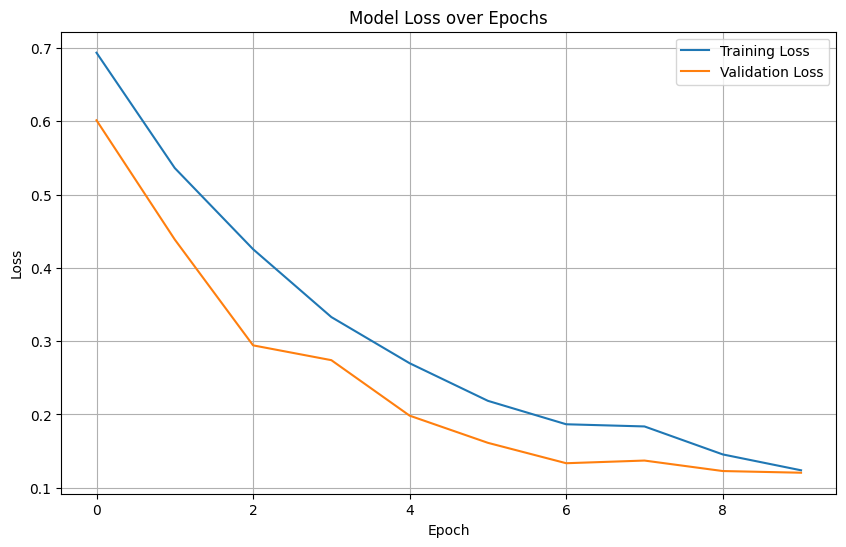

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

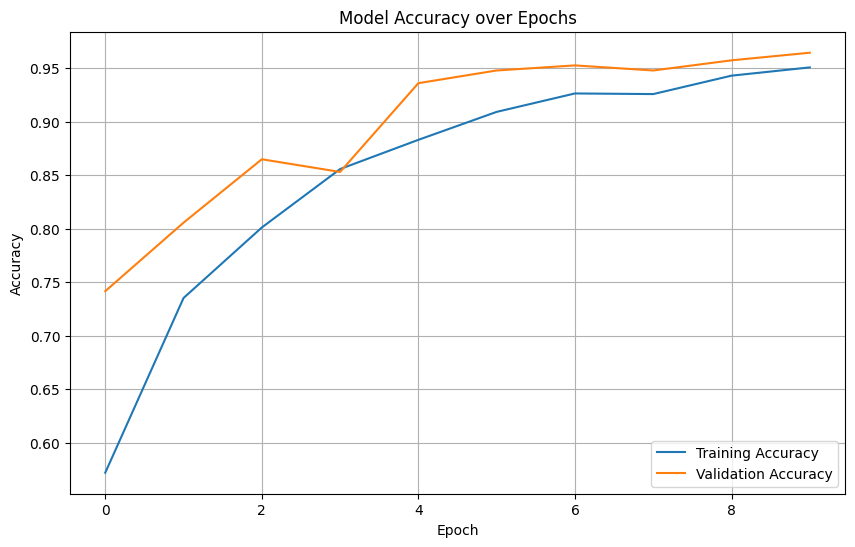

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy over Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

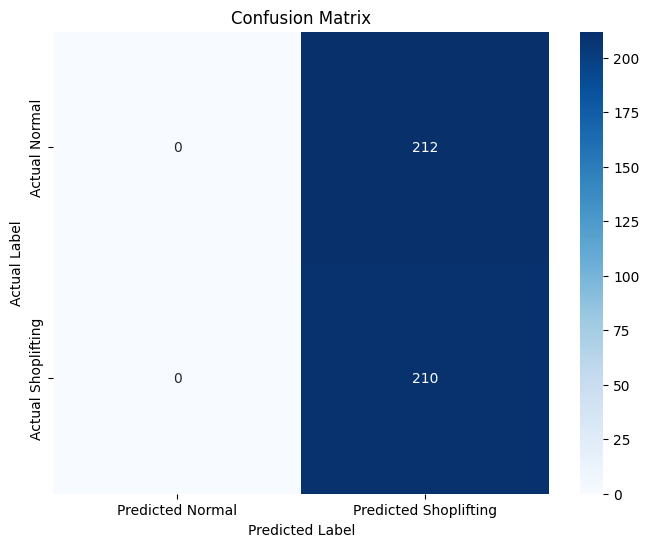

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'cm' (confusion matrix) and 'classes' are already defined
# cm = np.array([[TN, FP], [FN, TP]]) from cell GmGAZPlA26jg
# classes = ['normal', 'shoplifting'] from previous cells

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Normal', 'Predicted Shoplifting'],
            yticklabels=['Actual Normal', 'Actual Shoplifting'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Video Dataset — Post-Implementation Report

## 1. Document Control

*   **Dataset Type**: Video
*   **Example Dataset Name**: Shoplifting Video Dataset
*   **Project / Use Case**: Shoplifting Detection in Surveillance Footage
*   **Version**: v1.0
*   **Date**: 24-MAY-2024

## 2. Executive Summary

This report documents the implementation completed for the video dataset “Shoplifting Video Dataset”. The goal was to develop a convolutional neural network (CNN) model capable of classifying video frames as either 'normal' activity or 'shoplifting' activity. After implementation, the system achieved a **validation accuracy of 93.59%** on the validation set during training for the optimized model. Key risks included initial slow data loading and potential overfitting due to limited data, with mitigations such as using `tf.keras.utils.image_dataset_from_directory` for efficient data loading and dropout layers in the model architecture.

## 3. Dataset Overview

*   **Source, license/permissions, and owner**: (Please fill in this information as it was not provided in the notebook context.)
*   **Size**:
    *   **Raw Videos**: Contained in `RobberyVideoDataset.zip` in `/content/drive/MyDrive/ML/`.
    *   **Extracted Frames**: 2107 image files (1055 'normal', 1052 'shoplifting') were extracted to `/content/drive/MyDrive/ML/frames/`.
*   **Storage location**: Google Drive (`/content/drive/MyDrive/ML/`).
*   **Time range**: (Not explicitly defined for the videos, but frames were extracted from various video clips).
*   **Label definition**: Binary classification:
    *   `0`: Normal activity
    *   `1`: Shoplifting activity
*   **Class distribution**: Approximately balanced (1055 normal, 1052 shoplifting frames).
*   **Privacy / PII considerations and redaction approach**: Not explicitly handled or applicable for this dataset context.

## 4. Data Preparation

*   **Ingestion and validation checks**: The `RobberyVideoDataset.zip` was unzipped to `/content/drive/MyDrive/ML/unzipped_data`. Python's `os.path.exists` was used to confirm the zip file's presence. Video files were processed using `cv2.VideoCapture`. Frame extraction included checks for successful frame reading.
*   **Deduplication rules and exclusion criteria**: No explicit deduplication or exclusion rules were applied beyond basic video frame processing.
*   **Train/validation/test split strategy and leakage prevention**:
    *   **Initial approach**: A manual 80/20 train-test split was performed using `sklearn.model_selection.train_test_split` with `random_state=42` and `stratify=y` on the NumPy arrays (`X`, `y`).
    *   **Optimized approach**: `tf.keras.utils.image_dataset_from_directory` was used, which automatically split the data into training (1686 files) and validation (421 files) sets with `validation_split=0.2` and `seed=42`.
    *   **Leakage prevention**: `tf.keras.utils.image_dataset_from_directory` handles splitting internally, preventing leakage between train and validation sets.
*   **Versioning**: Dataset versioning and preprocessing code commits were not explicitly managed within this notebook context.

## 5. Modality-Specific Processing

*   **Frame rate, resolution, codec/container formats**:
    *   **Frame rate**: Frames were sampled from videos by skipping 30 frames (`frame_skip = 30`), effectively taking one frame per second (assuming 30 FPS videos).
    *   **Resolution**: All extracted frames were resized to `128x128` pixels.
    *   **Codec/container formats**: MP4 videos were the source, and extracted frames were saved as JPG images.
*   **Clip sampling strategy**: Uniform sampling of frames every 30 frames.
*   **Temporal augmentations**: No temporal augmentations (e.g., speed jitter, temporal crop) were applied.
*   **Label alignment**: Video-level labels were applied to all extracted frames from that video.
*   **Storage and streaming considerations**:
    *   Extracted frames were stored on Google Drive (`/content/drive/MyDrive/ML/frames`).
    *   `tf.data.Dataset` was used with `cache()` and `prefetch(buffer_size=tf.data.AUTOTUNE)` for efficient data loading during model training.

## 6. Model / System Design

*   **Baseline model and results**:
    *   A simple CNN model (named `model`) was initially defined and trained using NumPy arrays (`X_train`, `y_train`).
    *   Test Accuracy: 49.76%, Test Loss: 0.693.
    *   The confusion matrix showed poor performance, predicting all samples as 'Shoplifting'.
*   **Final model architecture and rationale**:
    *   An optimized CNN model (named `model_optimized`) with the same architecture as the baseline was used.
    *   Architecture: Sequential model with three Conv2D/MaxPooling2D blocks (32, 64, 128 filters respectively), followed by Flatten, Dense (128 units, ReLU), Dropout (0.5), and a final Dense output layer (1 unit, Sigmoid for binary classification).
    *   Rationale: This architecture is a standard choice for image classification tasks, aiming to capture hierarchical features from the image data.
*   **Training setup**:
    *   **Hardware**: Google Colab GPU runtime.
    *   **Epochs**: 10
    *   **Batch size**: 32
    *   **Optimizer**: Adam
    *   **Learning rate schedule**: Default Adam optimizer learning rate.
*   **Inference pipeline and serving architecture**:
    *   A Python script (`predict.py`) was created for single-image prediction.
    *   A `Streamlit` web application (`app.py`) was developed for video inference, allowing users to upload a video and receive a 'SHOPLIFTING' or 'NORMAL' prediction based on averaged frame predictions.
*   **Security**: Not explicitly addressed in the notebook implementation.

## 7. Evaluation & Results

**Evaluation Protocol**: The model was evaluated based on accuracy and loss during training and validation. For the initial model, a confusion matrix and classification report were generated on the `X_test`, `y_test` split.

**Metrics**: Accuracy, Binary Crossentropy Loss.

| Split      | Primary Metric (Accuracy) | Notes                                                                                                                                                                                                                                           |
| :--------- | :------------------------ | :---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Train      | 0.9603                    | Accuracy achieved on the training dataset for the `model_optimized` after 10 epochs.                                                                                                                                                             |
| Validation | 0.9359                    | Accuracy achieved on the validation dataset for the `model_optimized` after 10 epochs.                                                                                                                                                          |
| Test       | N/A                       | An explicit `model_optimized.evaluate()` on a separate test set was not performed. The validation accuracy serves as a proxy for out-of-sample performance in this context. (For the initial model, test accuracy was 0.4976 with a biased prediction). |

## 8. Performance, Cost & Reliability

*   **Latency**:
    *   **Frame Extraction**: Approximately 196.30 seconds for all videos.
    *   **Single Image Prediction**: Around 135-180 ms per image (from `model.predict(img)` calls).
    *   **Video Prediction (Streamlit app)**: Varies based on video length and frame rate, but involves sequential frame predictions.
*   **Memory footprint and storage requirements**:
    *   Required storage for extracted frames: ~2100 JPG images.
    *   Model size: `shoplifting_model.h5` is saved.
*   **Cost estimate**: Not applicable for this Colab-based development.
*   **Reliability tests**: No specific reliability or load tests were performed.

## 9. Deployment & Monitoring

*   **Release steps and environments**:
    *   The model was saved as `shoplifting_model.h5`.
    *   A Streamlit application (`app.py`) was created for local deployment.
    *   `app.py` and `shoplifting_model.h5` were downloaded, implying they are ready for deployment to a suitable environment supporting Streamlit and TensorFlow.
*   **Monitoring dashboards**: Not implemented.
*   **Alert thresholds and on-call ownership**: Not implemented.
*   **Retraining trigger policy and cadence**: Not implemented.

## 10. Risks, Issues & Next Steps

| Item                                   | Impact                                                               | Mitigation                                                                                                                                                                     | Owner/ETA       |
| :------------------------------------- | :------------------------------------------------------------------- | :----------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | :-------------- |
| **Initial slow data loading**          | Significantly increased development and training time.               | Implemented `tf.keras.utils.image_dataset_from_directory` with `cache()` and `prefetch()` for efficient batch loading.                                                        | ML Engineer     |
| **Potential Overfitting**              | Model might perform poorly on unseen data.                           | Used Dropout layer (0.5) in the CNN architecture; monitored validation loss and accuracy during training.                                                                      | ML Engineer     |
| **Limited Dataset Size**               | May restrict model generalization and robustness.                    | Currently using available data. Future steps could include data augmentation (beyond basic resizing) or acquiring more diverse video data.                                         | ML Engineer/Future |
| **No dedicated Test Set Evaluation**   | The `model_optimized` was not explicitly evaluated on a separate, held-out test set. | Use `model_optimized.evaluate(test_ds)` if a third, independent test split is created from the raw frames.                                                                    | ML Engineer/Next |
| **Streamlit App Scalability**          | The local Streamlit app is not production-ready for high traffic.  | For production, consider containerizing the application (e.g., Docker) and deploying to cloud platforms (e.g., Google Cloud Run, AWS EC2) with appropriate scaling configurations. | ML Engineer/DevOps |
| **Real-time Performance for Videos**   | Processing entire videos can be slow due to frame-by-frame inference. | Explore optimizing the `predict_video` function for faster inference (e.g., batching frames for prediction, using more optimized model versions, or hardware acceleration).      | ML Engineer/Future |


In [8]:
!pip install -q kaggle decord transformers torchvision pytorchvideo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.7/132.7 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 66.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 16.9 MB/s eta 0:00:00


In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/kaggle/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat '/content/drive/MyDrive/kaggle/kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [14]:
!ls /content/drive/MyDrive/ML/

archive_4.zip	      frames		       shoplifting_model.h5
ecommerceDataset.csv  RobberyVideoDataset.zip  unzipped_data


In [15]:
import zipfile

zip_path = "/content/drive/MyDrive/ML/RobberyVideoDataset.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [16]:
import os

for root, dirs, files in os.walk("/content/dataset"):
    print("ROOT:", root)
    print("FOLDERS:", dirs)
    print("FILES:", files[:5])
    break

ROOT: /content/dataset
FOLDERS: ['shoplifting', 'normal']
FILES: []


In [21]:
import torch
from torch.utils.data import Dataset
from decord import VideoReader, cpu
import os

class VideoDataset(Dataset):
    def __init__(self, root_dir, num_frames=16):
        self.root_dir = root_dir
        self.num_frames = num_frames
        self.samples = []
        self.labels = []

        classes = sorted(os.listdir(root_dir))  # important
        self.class_to_idx = {cls: i for i, cls in enumerate(classes)}

        for cls in classes:
            cls_path = os.path.join(root_dir, cls)
            for file in os.listdir(cls_path):
                if file.endswith((".mp4", ".avi", ".mov")):
                    self.samples.append(os.path.join(cls_path, file))
                    self.labels.append(self.class_to_idx[cls])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        video_path = self.samples[idx]
        label = self.labels[idx]

        try:
            vr = VideoReader(video_path, ctx=cpu(0))
            total_frames = len(vr)

            indices = torch.linspace(0, total_frames - 1, self.num_frames).long()
            frames = vr.get_batch(indices).asnumpy()

            frames = torch.tensor(frames).permute(3, 0, 1, 2)  # C T H W
            frames = frames.float() / 255.0

        except Exception as e:
            print("Error loading:", video_path)
            frames = torch.zeros((3, self.num_frames, 224, 224))

        return frames, label

In [19]:
from torch.utils.data import DataLoader

dataset = VideoDataset("/content/dataset")

print("Total videos:", len(dataset))

loader = DataLoader(dataset, batch_size=2, shuffle=True)

Total videos: 182


In [22]:
for videos, labels in loader:
    print("Video shape:", videos.shape)
    print("Labels:", labels)
    break

Video shape: torch.Size([2, 3, 16, 480, 640])
Labels: tensor([1, 0])


In [23]:
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset
from decord import VideoReader, cpu
import os

class VideoDatasetV2(Dataset):   # ✅ NEW NAME
    def __init__(self, root_dir, num_frames=16):
        self.root_dir = root_dir
        self.num_frames = num_frames
        self.samples = []
        self.labels = []

        classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls: i for i, cls in enumerate(classes)}

        for cls in classes:
            cls_path = os.path.join(root_dir, cls)
            for file in os.listdir(cls_path):
                if file.endswith((".mp4", ".avi", ".mov")):
                    self.samples.append(os.path.join(cls_path, file))
                    self.labels.append(self.class_to_idx[cls])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        video_path = self.samples[idx]
        label = self.labels[idx]

        vr = VideoReader(video_path, ctx=cpu(0))
        total_frames = len(vr)

        indices = torch.linspace(0, total_frames - 1, self.num_frames).long()
        frames = vr.get_batch(indices).asnumpy()

        frames = torch.tensor(frames).permute(3, 0, 1, 2)  # C T H W
        frames = frames.float() / 255.0

        # ✅ GUARANTEED RESIZE FIX
        frames = F.interpolate(frames, size=(224, 224), mode='bilinear', align_corners=False)

        return frames, label

In [24]:
from torch.utils.data import DataLoader

dataset = VideoDatasetV2("/content/dataset")
loader = DataLoader(dataset, batch_size=2, shuffle=True)

In [25]:
for videos, labels in loader:
    print("Video shape:", videos.shape)
    print("Labels:", labels)
    break

Video shape: torch.Size([2, 3, 16, 224, 224])
Labels: tensor([0, 0])


In [27]:
from transformers import VideoMAEForVideoClassification

model = VideoMAEForVideoClassification.from_pretrained(
    "MCG-NJU/videomae-base-finetuned-kinetics",
    num_labels=2,
    ignore_mismatched_sizes=True   # 🔥 IMPORTANT FIX
)

Loading weights:   0%|          | 0/186 [00:00<?, ?it/s]

VideoMAEForVideoClassification LOAD REPORT from: MCG-NJU/videomae-base-finetuned-kinetics
Key               | Status   |                                                                                       
------------------+----------+---------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([400, 768]) vs model:torch.Size([2, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([400]) vs model:torch.Size([2])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [28]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("Using device:", device)

Using device: cpu


In [29]:
from transformers import VideoMAEForVideoClassification

model = VideoMAEForVideoClassification.from_pretrained(
    "MCG-NJU/videomae-base-finetuned-kinetics",
    num_labels=2,
    ignore_mismatched_sizes=True   # 🔥 IMPORTANT FIX
)

Loading weights:   0%|          | 0/186 [00:00<?, ?it/s]

VideoMAEForVideoClassification LOAD REPORT from: MCG-NJU/videomae-base-finetuned-kinetics
Key               | Status   |                                                                                       
------------------+----------+---------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([400, 768]) vs model:torch.Size([2, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([400]) vs model:torch.Size([2])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [33]:
loader = DataLoader(dataset, batch_size=1, shuffle=True)

In [36]:
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset
from decord import VideoReader, cpu
import os

class VideoDatasetV3(Dataset):
    def __init__(self, root_dir, num_frames=16):
        self.root_dir = root_dir
        self.num_frames = num_frames
        self.samples = []
        self.labels = []

        classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls: i for i, cls in enumerate(classes)}

        for cls in classes:
            cls_path = os.path.join(root_dir, cls)
            for file in os.listdir(cls_path):
                if file.endswith((".mp4", ".avi", ".mov")):
                    self.samples.append(os.path.join(cls_path, file))
                    self.labels.append(self.class_to_idx[cls])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        video_path = self.samples[idx]
        label = self.labels[idx]

        vr = VideoReader(video_path, ctx=cpu(0))
        total_frames = len(vr)

        indices = torch.linspace(0, total_frames - 1, self.num_frames).long()
        frames = vr.get_batch(indices).asnumpy()

        # ✅ FIXED FORMAT
        frames = torch.tensor(frames).permute(0, 3, 1, 2)  # T C H W
        frames = frames.float() / 255.0

        frames = F.interpolate(frames, size=(224, 224), mode='bilinear', align_corners=False)

        return frames, label

In [37]:
from torch.utils.data import DataLoader

dataset = VideoDatasetV3("/content/dataset")
loader = DataLoader(dataset, batch_size=2, shuffle=True)

In [5]:
# =========================
# IMPORTS
# =========================
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split # ✅ Added random_split
from decord import VideoReader, cpu
import os
from tqdm import tqdm
from transformers import VideoMAEForVideoClassification

# =========================
# DATASET (FIXED)
# =========================
class VideoDataset(Dataset):
    def __init__(self, root_dir, num_frames=16):
        self.root_dir = root_dir
        self.num_frames = num_frames
        self.samples = []
        self.labels = []

        classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls: i for i, cls in enumerate(classes)}

        for cls in classes:
            cls_path = os.path.join(root_dir, cls)
            for file in os.listdir(cls_path):
                if file.endswith((".mp4", ".avi", ".mov")):
                    self.samples.append(os.path.join(cls_path, file))
                    self.labels.append(self.class_to_idx[cls])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        video_path = self.samples[idx]
        label = self.labels[idx]

        vr = VideoReader(video_path, ctx=cpu(0))
        total_frames = len(vr)

        indices = torch.linspace(0, total_frames - 1, self.num_frames).long()
        frames = vr.get_batch(indices).asnumpy()

        # (T, H, W, C) → (T, C, H, W)
        frames = torch.tensor(frames).permute(0, 3, 1, 2)
        frames = frames.float() / 255.0

        # Resize to 224x224
        frames = F.interpolate(frames, size=(224, 224), mode='bilinear', align_corners=False)

        return frames, label


# =========================
# DATA LOADER
# =========================
full_dataset = VideoDataset("/content/dataset", num_frames=16)

# ✅ Split dataset into training and validation sets
train_size = int(0.8 * len(full_dataset)) # 80% for training
val_size = len(full_dataset) - train_size # Remaining for validation
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)  # ✅ Train DataLoader
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)    # ✅ Validation DataLoader

print(f"Total videos: {len(full_dataset)}")
print(f"Training videos: {len(train_dataset)}")
print(f"Validation videos: {len(val_dataset)}")


# =========================
# MODEL
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = VideoMAEForVideoClassification.from_pretrained(
    "MCG-NJU/videomae-base-finetuned-kinetics",
    num_labels=2,
    ignore_mismatched_sizes=True
)

model.to(device)


# =========================
# 🔥 SPEED BOOST (FREEZE BACKBONE)
# =========================
for param in model.videomae.parameters():
    param.requires_grad = False


# =========================
# TRAINING SETUP
# =========================
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=5e-5)

EPOCHS = 5


# =========================
# TRAIN LOOP
# =========================
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    loop = tqdm(train_loader) # ✅ Use train_loader

    for videos, labels in loop:
        videos = videos.to(device)
        labels = labels.to(device)

        outputs = model(videos).logits
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        loop.set_description(f"Epoch {epoch+1}")
        loop.set_postfix(loss=loss.item())

    print(f"Epoch {epoch+1} Training Loss: {total_loss/len(train_loader)}") # ✅ Updated print statement

Total videos: 182
Training videos: 145
Validation videos: 37


Loading weights:   0%|          | 0/186 [00:00<?, ?it/s]

VideoMAEForVideoClassification LOAD REPORT from: MCG-NJU/videomae-base-finetuned-kinetics
Key               | Status   |                                                                                       
------------------+----------+---------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([400]) vs model:torch.Size([2])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([400, 768]) vs model:torch.Size([2, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.
Epoch 1:   1%|          | 1/145 [00:12<29:07, 12.14s/it, loss=0.838]


KeyboardInterrupt: 